In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("train_team_track.parquet", engine='fastparquet')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4342000 entries, 0 to 4341999
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   office_from_id  int64         
 1   route_id        int64         
 2   timestamp       datetime64[ns]
 3   status_1        int64         
 4   status_2        int64         
 5   status_3        int64         
 6   status_4        int64         
 7   status_5        int64         
 8   status_6        int64         
 9   status_7        int64         
 10  status_8        int64         
 11  target_2h       float64       
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 397.5 MB


In [15]:
df.isna().sum()

office_from_id    0
route_id          0
timestamp         0
status_1          0
status_2          0
status_3          0
status_4          0
status_5          0
status_6          0
status_7          0
status_8          0
target_2h         0
dtype: int64

In [4]:
df.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0


In [49]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [43]:
last_index_4_29 = ((df['office_from_id']!=4) | (df['route_id']!=29)).idxmax()

In [52]:
df_4_29 = df.iloc[:last_index_4_29]
df_4_29

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4337,4,29,2025-05-30 08:30:00,913,142,393,54,474,398,9446,167,96.0
4338,4,29,2025-05-30 09:00:00,1215,176,448,123,398,0,362,38,79.0
4339,4,29,2025-05-30 09:30:00,1505,229,736,152,692,790,0,0,73.0
4340,4,29,2025-05-30 10:00:00,1735,228,1132,185,153,99,0,0,64.0


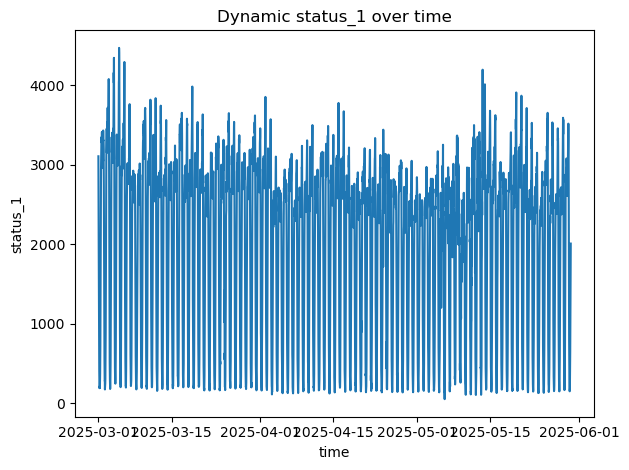

In [53]:
plt.plot(df_4_29.timestamp, df_4_29.status_1)
plt.title('Dynamic status_1 over time')
plt.xlabel('time')
plt.ylabel('status_1')
plt.tight_layout()
plt.show()

In [3]:
variable_features = df.columns[3:]
static_features = df.columns[:2]

In [7]:
df[variable_features].describe()

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
count,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06,4.342000e+06
mean,1.310749e+03,1.469986e+02,1.278569e+03,1.102996e+03,1.555774e+03,1.555738e+03,2.243071e+03,9.161675e+02,6.874518e+01
std,2.501866e+03,2.066661e+02,2.310502e+03,1.740375e+03,2.194728e+03,2.255213e+03,4.913774e+03,1.872031e+03,6.748811e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.400000e+01,0.000000e+00,6.600000e+01,1.820000e+02,1.100000e+02,0.000000e+00,0.000000e+00,1.900000e+01
50%,1.230000e+02,5.900000e+01,1.440000e+02,3.480000e+02,6.640000e+02,6.410000e+02,2.600000e+01,2.300000e+01,4.800000e+01
75%,1.345000e+03,2.010000e+02,1.463000e+03,1.301000e+03,1.894000e+03,1.944000e+03,1.744000e+03,1.033000e+03,1.000000e+02
max,3.649100e+04,1.715000e+04,2.602000e+04,2.117000e+04,2.656500e+04,2.770200e+04,7.631900e+04,5.203900e+04,1.517000e+03


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
df_sample, _ = train_test_split(
    df, 
    train_size=10000,  
    stratify=df[static_features], 
    random_state=1
)

In [6]:
df_sample.shape

(10000, 12)

In [7]:
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
corr_df = df.corr(method='spearman')
corr_df_sample = df_sample.corr(method='spearman')

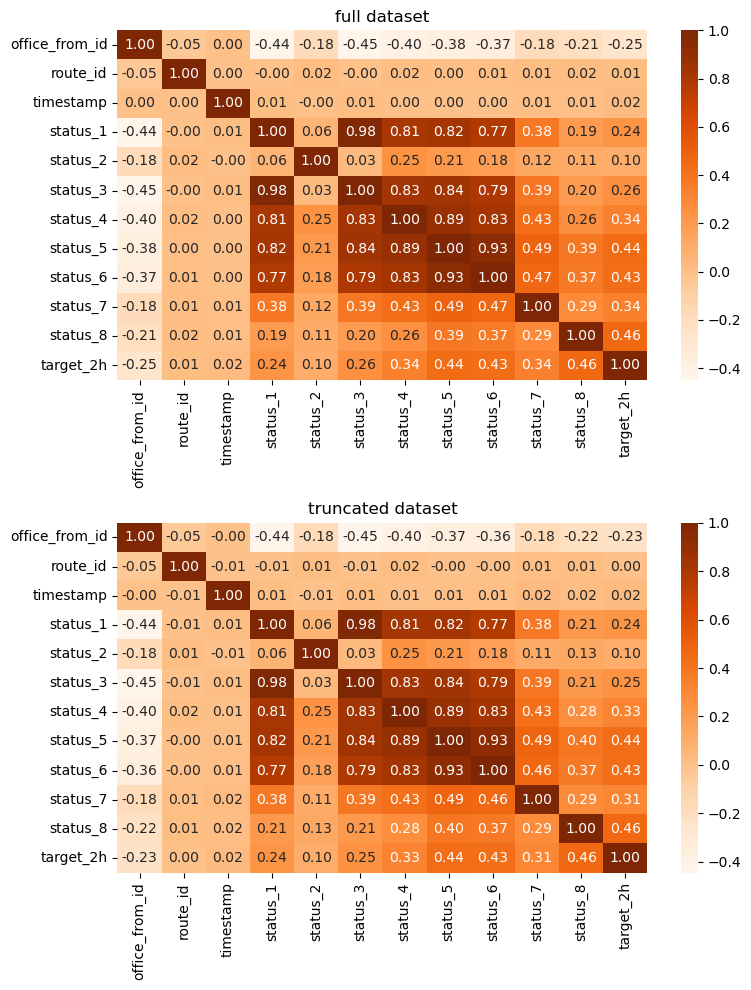

In [9]:
_, axes = plt.subplots(2, 1, figsize=(8, 10))

ax_hm_df = sns.heatmap(data=corr_df, annot=True, cmap='Oranges', fmt='.2f', ax=axes[0])
ax_hm_df.set_xticklabels(ax_hm_df.get_xticklabels(), fontsize=10)
ax_hm_df.set_yticklabels(ax_hm_df.get_yticklabels(), fontsize=10)
axes[0].set_title('full dataset')

ax_hm_df_sample = sns.heatmap(data=corr_df_sample, annot=True, cmap='Oranges', fmt='.2f', ax=axes[1])
ax_hm_df_sample.set_xticklabels(ax_hm_df_sample.get_xticklabels(), fontsize=10)
ax_hm_df_sample.set_yticklabels(ax_hm_df_sample.get_yticklabels(), fontsize=10)
axes[1].set_title('truncated dataset')

plt.tight_layout()
plt.show()

In [17]:
transformed_df_sample = np.log1p(df_sample[variable_features])

In [21]:
transformed_df_sample.min()

status_1     0.0
status_2     0.0
status_3     0.0
status_4     0.0
status_5     0.0
status_6     0.0
status_7     0.0
status_8     0.0
target_2h    0.0
dtype: float64

In [24]:
def density(feature, df):
    sns.displot(
        data=df,
        x=feature,
        kind='kde',
        color='orange'
    )
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

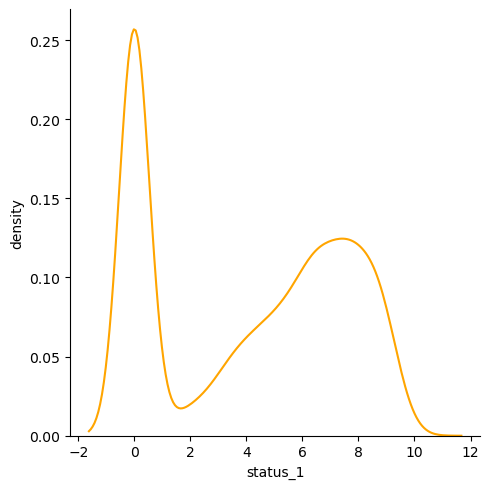

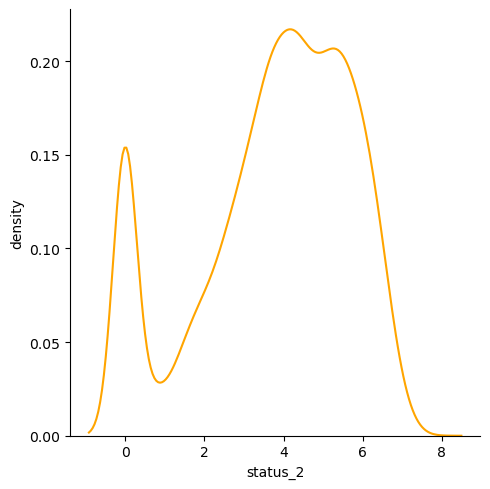

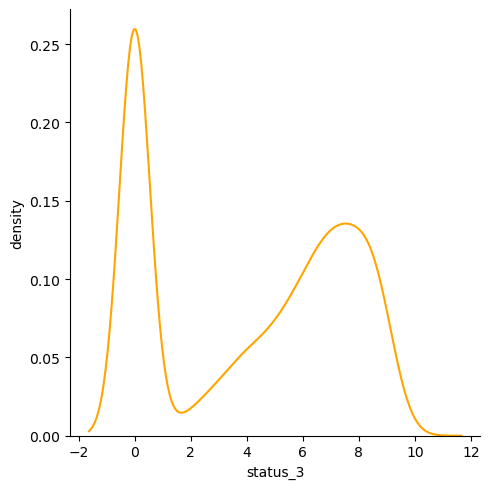

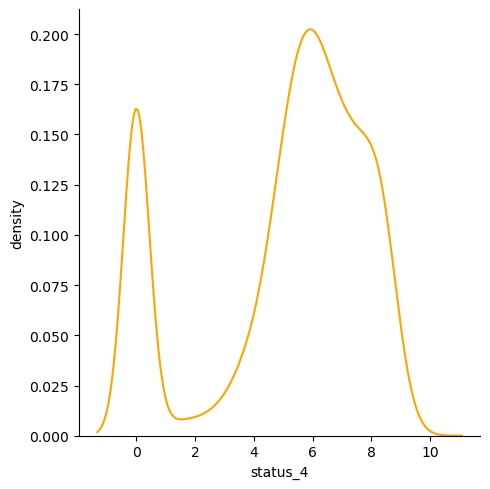

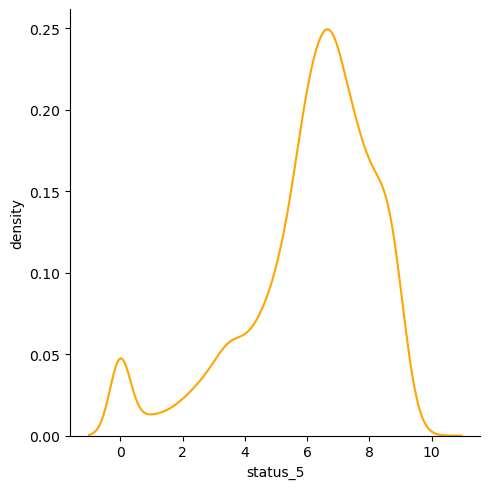

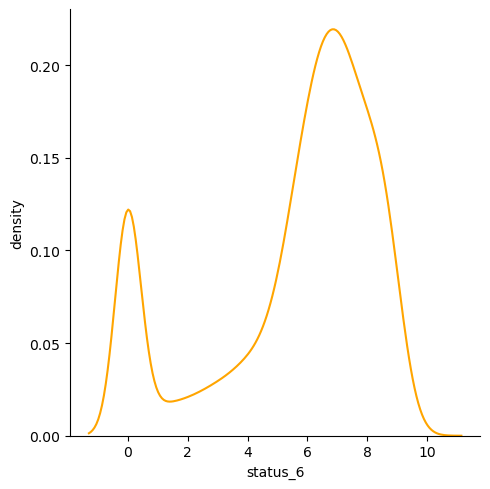

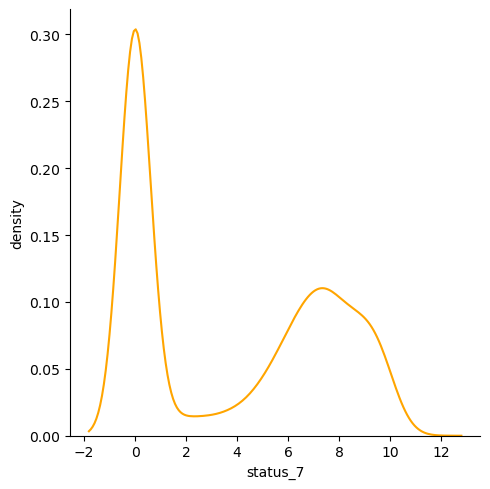

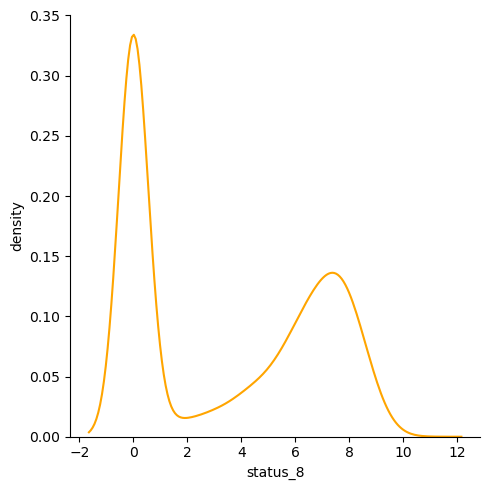

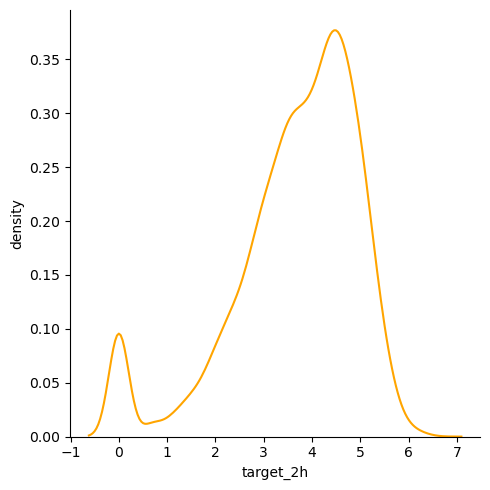

In [26]:
for feature in df_sample.columns[3:]:
    density(feature, transformed_df_sample)

In [29]:
def density_hist(feature, df):
    plt.hist(df[feature], bins=50, density=True)
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

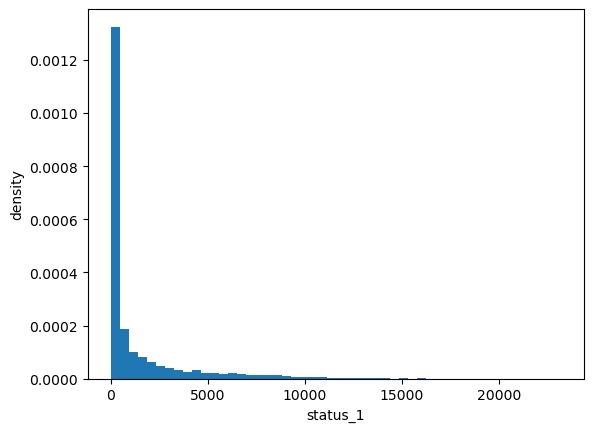

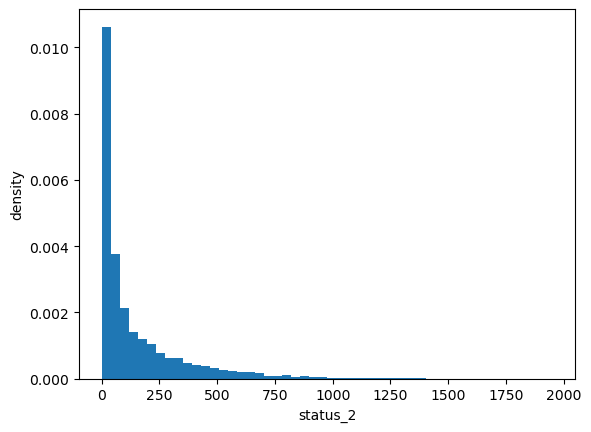

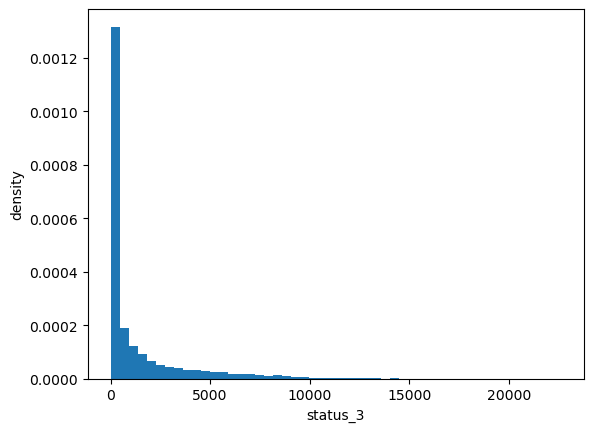

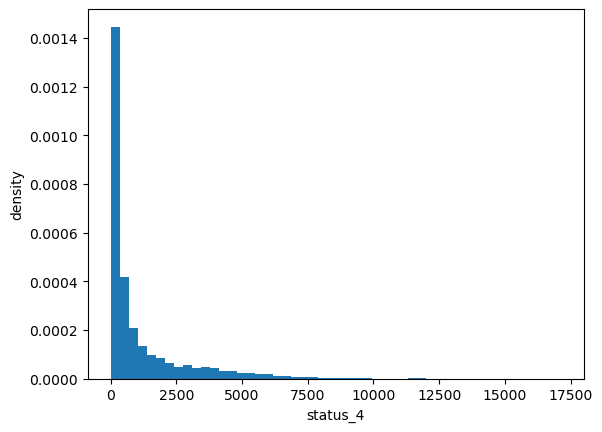

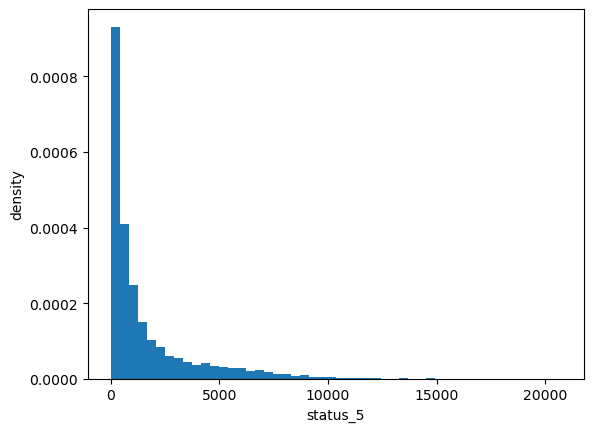

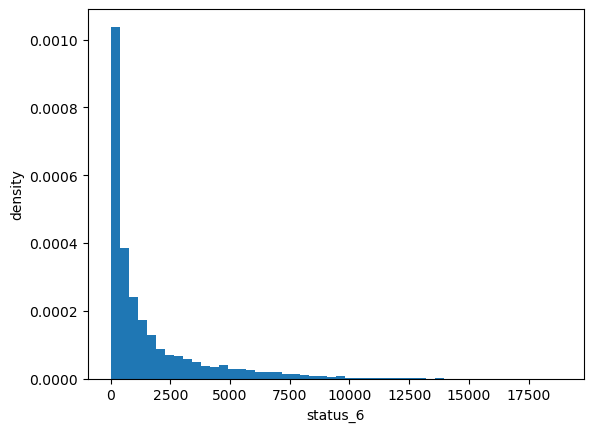

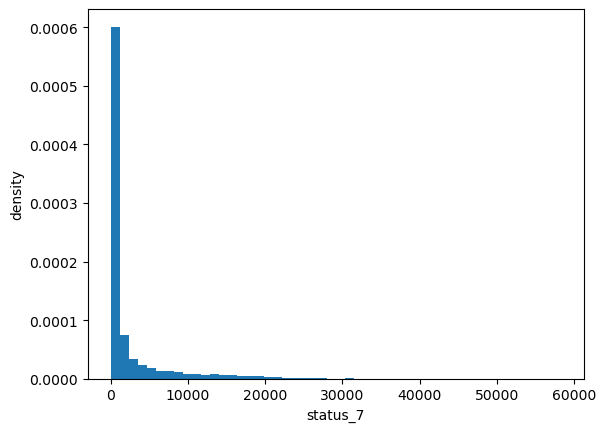

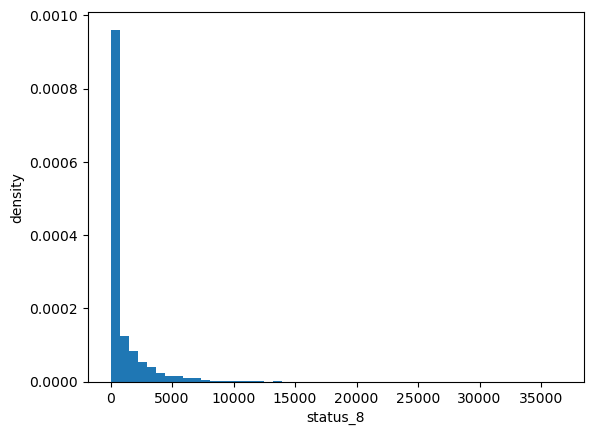

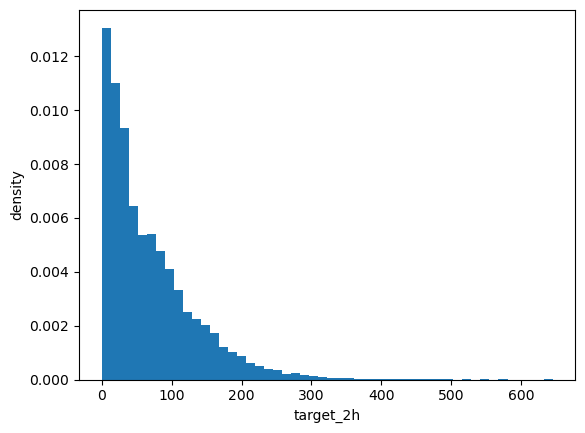

In [30]:
for feature in df_sample.columns[3:]:
    density_hist(feature, df_sample)